# Шаг 1

Задание:\
Загрузка данных. Загрузите датасет, содержащий числовые признаки (например, Boston Housing, California Housing или другой подходящий из UCI или Kaggle). Импортируйте необходимые библиотеки для работы с данными, визуализацией и анализом. Загрузите данные в DataFrame и просмотрите первые строки, чтобы ознакомиться с набором данных.

In [ ]:
# импорты
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
#В качестве данных был взят датасет квартир в Москве
flat_df = pd.read_csv("/content/drive/MyDrive/Data/Moscow_flats.csv")
flat_df.head(10)

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation
5,7150000.0,Secondary,Опалиха,6.0,Moscow region,1.0,38.4,18.0,8.0,8.0,18,European-style renovation
6,7400000.0,Secondary,Нахабино,11.0,Moscow region,1.0,33.0,16.0,8.0,7.0,7,European-style renovation
7,7500000.0,Secondary,Строгино,27.0,Moscow region,1.0,25.0,14.8,8.7,16.0,34,European-style renovation
8,7800000.0,Secondary,Красногорская,6.0,Moscow region,1.0,41.8,18.0,10.0,6.0,17,Cosmetic
9,7999999.0,Secondary,Тушинская,35.0,Moscow region,1.0,44.0,19.0,11.0,11.0,24,Designer


# Шаг 2

Задание:\
Исследование корреляций. Постройте корреляционную матрицу для числовых признаков. Визуализируйте корреляционную матрицу с помощью тепловой карты (heatmap). Определите пары признаков с наибольшей и наименьшей корреляцией. Для этого найдите максимальные и минимальные значения в корреляционной матрице, исключив диагональные элементы.

Максимальная корреляция: 0.9066037886868156
Признаки с максимальной корреляцией: Index(['Area', 'Living area'], dtype='object')
Максимальная корреляция: -0.10538192708946409
Признаки с максимальной корреляцией: Index(['Price', 'Minutes to metro'], dtype='object')


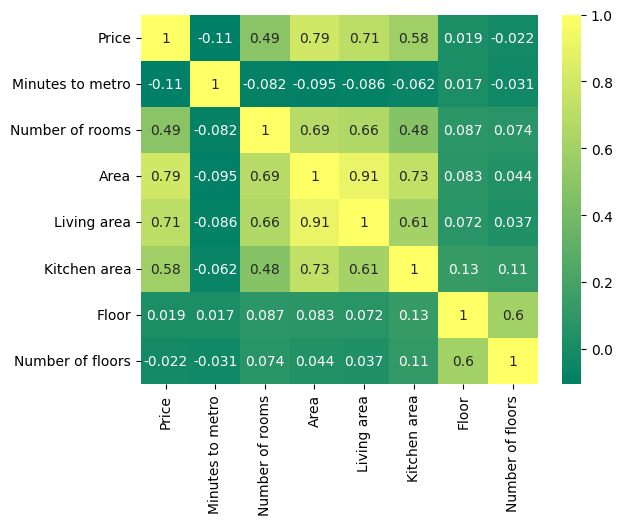

In [4]:
#Корреляционная матрица и её тепловая карта
corr_matrix = flat_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="summer")

#Минимум и максимум корреляционной матрицы
cleaned_matrix = corr_matrix - np.eye(corr_matrix.shape[0])
max_corr = cleaned_matrix.values.max()
print(f"Максимальная корреляция: {max_corr}")
print(f"Признаки с максимальной корреляцией: {cleaned_matrix[cleaned_matrix.values == max_corr].index}")

min_corr = cleaned_matrix.values.min()
print(f"Максимальная корреляция: {min_corr}")
print(f"Признаки с максимальной корреляцией: {cleaned_matrix[cleaned_matrix.values == min_corr].index}")

# Шаг 3

Задание:\
Построение графиков зависимостей. Выберите два признака с сильной корреляцией. Замените на реальные названия признаков из вашего датасета. Постройте диаграмму рассеяния (scatter plot) и добавьте линию регрессии.

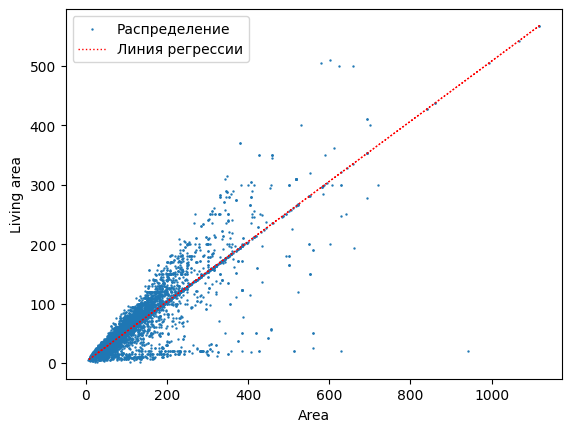

In [5]:
#Строим диаграмму рассеяния
x, y = flat_df["Area"], flat_df["Living area"]
plt.scatter(x, y, s=0.5, label="Распределение")
plt.xlabel("Area")
plt.ylabel("Living area")

#Добавляем линию регрессии
coeffs = np.polyfit(x, y, 1)
p = np.poly1d(coeffs)
plt.plot(x, p(x), c="red", lw=1, ls=":", label="Линия регрессии")
plt.legend()

# Шаг 4

Задание:\
Подготовка данных. Нормализуйте данные, чтобы привести все
признаки к одному масштабу, используя стандартное масштабирование. Разделите данные на обучающую и тестовую выборки в пропорции 80/20.

In [6]:
#Нормализатор
scaler = StandardScaler()

#Разделение на фичи и таргет
features = flat_df[["Minutes to metro", "Number of rooms", "Area", "Living area", "Kitchen area", "Floor", "Number of floors"]]
target = flat_df["Price"] / 1000

#Нормализируем фичи
features_norm = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)
display(features_norm)

#Разделение на тестовую и обучающую выборку
X_train, X_test, y_train, y_test = train_test_split(features_norm, target, test_size = 0.2)
print(X_train.shape)
print(X_test.shape)

,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
0,-0.949114,-0.684669,-0.605069,-0.719189,-0.529779,2.094025,0.863466
1,-1.593826,-0.684669,-0.333009,-0.485737,-0.335677,-0.422588,-0.159125
2,0.340311,-0.684669,-0.398830,-0.585413,0.065466,0.107226,0.863466
3,-0.626758,-0.684669,-0.539248,-0.590659,-0.206276,0.372132,1.681539
4,-0.949114,-0.684669,-0.501218,-0.611644,-1.112084,-0.555041,-1.181716
...,...,...,...,...,...,...,...
22671,-0.626758,-1.341030,-0.588248,-0.669351,-0.982683,-0.687494,0.045393
22672,2.113269,-0.684669,-0.590442,-0.745419,-0.050995,0.239679,-0.159125
22673,2.919159,-1.341030,-0.789368,-0.616890,-0.581540,1.034399,0.045393
22674,0.340311,-0.028308,-0.520379,-0.433276,-0.775641,0.372132,-0.261384


(18140, 7)
(4536, 7)


# Шаг 5

Задание:\
Визуализация трендов. Используйте модель линейной регрессии для предсказания и постройте график распределения ошибок между предсказанными и реальными значениями. Постройте график ошибок (выбросов), чтобы оценить точность модели.

Intercept:  36094.581766888194


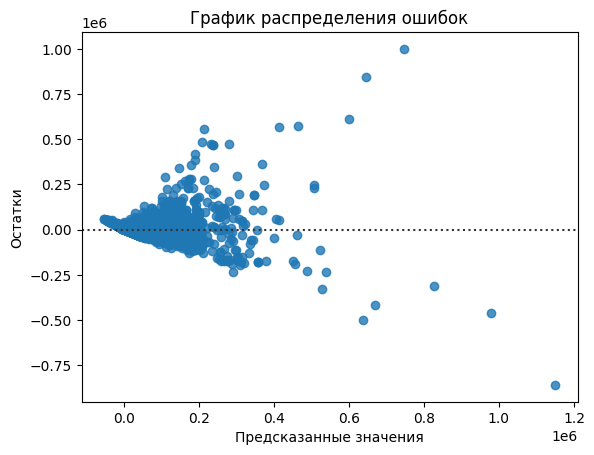

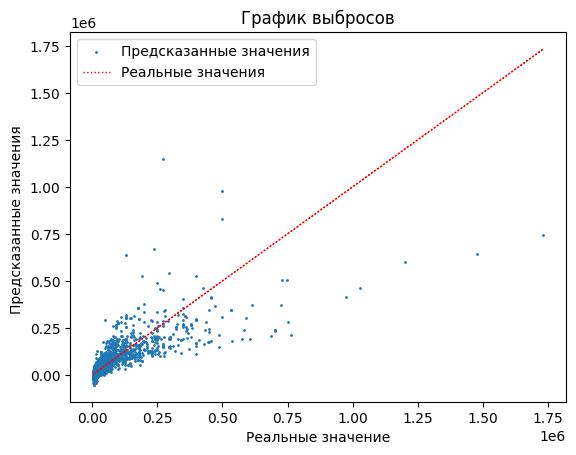

In [7]:
#Постороение модели
reg_model = LinearRegression().fit(X_train, y_train)

#Коэффициенты модели
print('Intercept: ',reg_model.intercept_)
list(zip(features.columns, reg_model.coef_))

#График распределения ошибок
y_pred = reg_model.predict(X_test)
sns.residplot(x=y_pred, y = y_test - y_pred)
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График распределения ошибок")
plt.show()

#График выбросов
plt.scatter(y_test, y_pred, s=1, label="Предсказанные значения")
plt.plot(y_test, y_test, ls=":", color="red", lw=1, label="Реальные значения")
plt.xlabel("Реальные значение")
plt.ylabel("Предсказанные значения ")
plt.title("График выбросов")
plt.legend()

# Шаг 6

Задание:\
Ответьте на вопросы. Как изменение одного признака влияет на другой? Как влияет масштабирование данных на качество модели?

Ответы:\
Изменится ли один признак при изменении другого зависит от того, насколько высок коэффициент корреляции между ними.\
Приведение признаков к одному масштабу важно для многих алгоритмов, таких как линейная регрессия, метод k-ближайших соседей и нейронные сети, поскольку они чувствительны к масштабам признаков. Например, если один признак имеет диапазон значений от 0 до 1, а другой — от 0 до 1000, алгоритм может неправильно оценивать значимость признаков.